### NPi recontruciton using min, max and ch (Used model)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygam import LinearGAM, s, l
from scipy.optimize import curve_fit
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression

import os
from dotenv import load_dotenv
from pathlib import Path
load_dotenv()

True

In [ ]:
# Load data
NPImeaures_noCHerro = Path(os.getenv(rf"NPI_noCHerror"))
df = pd.read_csv(NPImeaures_noCHerro)

df["eye"] = df["eye"].map({"left": 0, "right": 1})

df["redcap_repeat_instance"] = (
    df["redcap_repeat_instance"]
    .fillna(0)
    .astype(int)
)

df = df.dropna(subset=[
    "npi", "pupil_size", "pupil_min", "ch"
])
def z_score(x, mean, std):
    return (x - mean) / std

# use the z-scores from healthy controls
df_l = pd.read_csv(r"L:\Auditdata\CONNECT-ME\DTU\FrederikWeinan_Thesis\Pupilometri\HC_left_NPi.csv")
df_r = pd.read_csv(r"L:\Auditdata\CONNECT-ME\DTU\FrederikWeinan_Thesis\Pupilometri\HC_right_NPi.csv")
df_l = df_l.rename(columns=lambda c: c.replace("_left", ""))
df_r = df_r.rename(columns=lambda c: c.replace("_right", ""))

df_l["eye"] = "left"
df_r["eye"] = "right"

df_HC = pd.concat([df_l, df_r], ignore_index=True)

# z-score all used features based on healty distribution
df["z_pupil_size"] = z_score(df["pupil_size"], df_HC["pupil_size"].dropna().mean(), df_HC["pupil_size"].dropna().std())
df["z_pupil_min"]  = z_score(df["pupil_min"], df_HC["pupil_min"].dropna().mean(), df_HC["pupil_min"].dropna().std())
df["z_ch"] = z_score(df["ch"], df_HC["ch"].dropna().mean(), df_HC["ch"].dropna().std())

In [2]:
TARGET = "npi"
GROUP = "record_id"
FEATURES = [
    "z_pupil_size",
    "z_pupil_min",
    "z_ch"
]

df = pd.read_csv(r"done.csv")
X = df[FEATURES].copy()
y_raw = df[TARGET].astype(float).values
groups = df[GROUP].values


X_trans = X.copy()

In [3]:
X_trans.describe()

,z_pupil_size,z_pupil_min,z_ch
count,2074.000000,2074.000000,2074.000000
mean,-1.682018,-0.879761,-2.756401
std,1.186452,1.178566,1.769591
min,-3.467046,-2.720040,-5.822623
25%,-2.614650,-1.680752,-4.166587
50%,-2.040002,-1.167686,-2.841758
75%,-0.967325,-0.378353,-1.351325
max,2.614650,5.173286,2.457558


In [ ]:
# Models used

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

#  pupil min model
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

# #  pupil size model
# def sigmoid_plus_threshold_linear(x, A, k, x0, m, b, x_thresh):
#     return A * sigmoid(k * (x - x0)) + m * np.maximum(0, x - x_thresh) + b

# #  CH model
# def sigmoid_shifted(x, A, k, x0, b):
#     return A * sigmoid(k * (x - x0)) + b

# def pysr_min(x, a, b, c, d, e):
#     return a + b / (c + d * np.exp(-x) + e / x)

def pysr_min(x, a, b, c):
    return (a + b * x) / (x + c)

def pysr_ch(x, a, b):
    return np.log((a*x + b)**3)
p0_ch = [0.115, 1.244]

def pysr_size(x, a, b, c):
    return a * x**2 + b * x * np.exp(-x) + c
    # return x**2 * (a + b * (x + c)**2) + d
p0_size = [0.2648, 0.04682, -0.0916]


# Stratified CV setup

y_binned = pd.qcut(df["npi"], q=5, labels=False, duplicates="drop")

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores, mae_scores, r2_scores = [], [], []

all_true = []
all_pred = []
all_indices = []
all_repeat = []
all_eye = []

# CV LOOP

for fold, (train_idx, test_idx) in enumerate(
    cv.split(X_trans, y_binned, groups)
):

    print(f"\n--- Fold {fold+1} ---")

    X_train = X_trans.iloc[train_idx]
    X_test  = X_trans.iloc[test_idx]

    y_train_raw = y_raw[train_idx]
    y_test_raw  = y_raw[test_idx]


    # Logit transform

    y_train_scaled = np.clip(y_train_raw / 5, 1e-6, 1-1e-6)
    z_train = np.log(y_train_scaled / (1 - y_train_scaled))

    # Train GAM
    gam = LinearGAM(
        s(0, n_splines=10) +
        s(1, constraints='monotonic_dec', n_splines=10) +
        s(2, constraints='monotonic_inc', n_splines=10) 
    )

    from sklearn.neighbors import KernelDensity

    kde = KernelDensity(bandwidth=0.3).fit(z_train.reshape(-1,1))
    log_dens = kde.score_samples(z_train.reshape(-1,1))
    density_weights = 1 / np.exp(log_dens)
    density_weights /= density_weights.mean()
    cap = np.percentile(density_weights, 95)
    density_weights_capped = np.clip(density_weights, None, cap)
    density_weights_capped /= density_weights_capped.mean()

    gam.gridsearch(X_train, z_train, weights=density_weights_capped)


    # gam.gridsearch(X_train, z_train)


    # FIT  MODELS
    # Pupil size 
    x_vals_size = np.linspace(X_train.iloc[:,0].min(), X_train.iloc[:,0].max(), 200)

    X_fake = pd.DataFrame(
        np.tile(X_train.mean().values, (200,1)),
        columns=X_train.columns
    )
    X_fake.iloc[:,0] = x_vals_size

    y_gam_size = gam.partial_dependence(term=0, X=X_fake)
    try:
        params_size, _ = curve_fit(
            pysr_size,
            x_vals_size,
            y_gam_size,
            p0=p0_size,
            maxfev=20000
        )
        use_fallback_size = False
    except RuntimeError:
        print("failed")
        use_fallback_size = True


    #  Pupil min 
    x_vals_min = np.linspace(X_train.iloc[:,1].min(), X_train.iloc[:,1].max(), 200)

    X_fake = pd.DataFrame(
        np.tile(X_train.mean().values, (200,1)),
        columns=X_train.columns
    )
    X_fake.iloc[:,1] = x_vals_min

    y_gam_min = gam.partial_dependence(term=1, X=X_fake)

    params_min, _ = curve_fit(exp_decay, x_vals_min, y_gam_min, maxfev=20000)


    # pupil CH 
    x_vals_ch = np.linspace(X_train.iloc[:,2].min(), X_train.iloc[:,2].max(), 200)

    X_fake = pd.DataFrame(
        np.tile(X_train.mean().values, (200,1)),
        columns=X_train.columns
    )
    X_fake.iloc[:,2] = x_vals_ch

    y_gam_ch = gam.partial_dependence(term=2, X=X_fake)

    try:
        params_ch, _ = curve_fit(
            pysr_ch,
            x_vals_ch,
            y_gam_ch,
            p0=p0_ch,
            maxfev=20000
        )
        use_fallback_ch = False
    except RuntimeError:
        print("failed")
        use_fallback_ch = True


    # Intercept
    intercept = (
        gam._modelmat(np.zeros((1, X_train.shape[1]))) @ gam.coef_
    ).item()


    # MODEL

    # def f_size(x):
    #     if use_fallback_size:
    #         return np.interp(x, x_vals_size, y_gam_size)
    #     return size_pysr(x, *params_size)

    # def f_min(x):
    #     return exp_decay(x, *params_min)

    # def f_ch(x):
    #     if use_fallback_ch:
    #         return np.interp(x, x_vals_ch, y_gam_ch)
    #     return sigmoid_shifted(x, *params_ch)
    
    
    def f_min(x):
        return params_min[0] * np.exp(- params_min[1] * x) +  params_min[2]
        # return (params_min[0] + params_min[1] * x) / (x + params_min[2])

    def f_ch(x):
        return np.log((params_ch[0]*x + params_ch[1])**3)
        # return params_ch[0] * x + params_ch[1] * np.sin(params_ch[2] * x) + params_ch[3]

    def f_size(x):
        return params_size[0] * x**2 * np.log(x + params_size[1])
        # return x**2 * (params_size[0] + params_size[1] * (x + params_size[2])**2) + params_size[3]
        # return x * (params_size[0] * x + params_size[1]) + params_size[2] * (x**3 + params_size[3])**2
        # return (params_size[0] * x**3 + params_size[1]*x + params_size[2]) * np.sin(x + params_size[3])


    def predict_z(X):
        return (
            intercept
            + f_size(X.iloc[:,0].values)
            + f_min(X.iloc[:,1].values)
            + f_ch(X.iloc[:,2].values)
        )

    # CALIBRATION
    z_train_pred = predict_z(X_train)

    z_train_true = np.log(
        np.clip(y_train_raw/5, 1e-6, 1-1e-6) /
        (1 - np.clip(y_train_raw/5, 1e-6, 1-1e-6))
    )

    reg = LinearRegression().fit(
        z_train_pred.reshape(-1,1),
        z_train_true
    )

    a = reg.coef_[0]
    b = reg.intercept_

    print(f"Calibration: a={a:.3f}, b={b:.3f}")



    # TEST
    z_test_pred = predict_z(X_test)

    z_test_corrected = a * z_test_pred + b
    npi_pred = np.round(sigmoid(z_test_corrected) * 5,1)
    all_true.extend(y_test_raw)
    all_pred.extend(npi_pred)
    all_indices.extend(df.iloc[test_idx]["record_id"].values)
    all_repeat.extend(df.iloc[test_idx]["redcap_repeat_instance"].values)
    all_eye.extend(df.iloc[test_idx]["eye"].values)




    # EVALUATION
    rmse = np.sqrt(mean_squared_error(y_test_raw, npi_pred))
    mae  = mean_absolute_error(y_test_raw, npi_pred)
    r2   = r2_score(y_test_raw, npi_pred)

    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")

    rmse_scores.append(rmse)
    mae_scores.append(mae)
    r2_scores.append(r2)


# Results
print("\n=== FINAL CV RESULTS ===")
print(f"RMSE: {np.mean(rmse_scores):.4f} ± {np.std(rmse_scores):.4f}")
print(f"MAE:  {np.mean(mae_scores):.4f} ± {np.std(mae_scores):.4f}")
print(f"R2:   {np.mean(r2_scores):.4f} ± {np.std(r2_scores):.4f}")


--- Fold 1 ---


  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


Calibration: a=0.955, b=-0.862
RMSE: 0.1295
MAE:  0.0850
R2:   0.9788

--- Fold 2 ---


  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00


Calibration: a=0.975, b=-0.751
RMSE: 0.1165
MAE:  0.0682
R2:   0.9789

--- Fold 3 ---


...

Calibration: a=0.979, b=-0.866
RMSE: 0.1072
MAE:  0.0630
R2:   0.9817

--- Fold 4 ---


  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--


Calibration: a=0.992, b=-0.786
RMSE: 0.1047
MAE:  0.0644
R2:   0.9841

--- Fold 5 ---


  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Calibration: a=0.990, b=-0.911
RMSE: 0.1196
MAE:  0.0797
R2:   0.9701

=== FINAL CV RESULTS ===
RMSE: 0.1155 ± 0.0089
MAE:  0.0721 ± 0.0087
R2:   0.9787 ± 0.0047


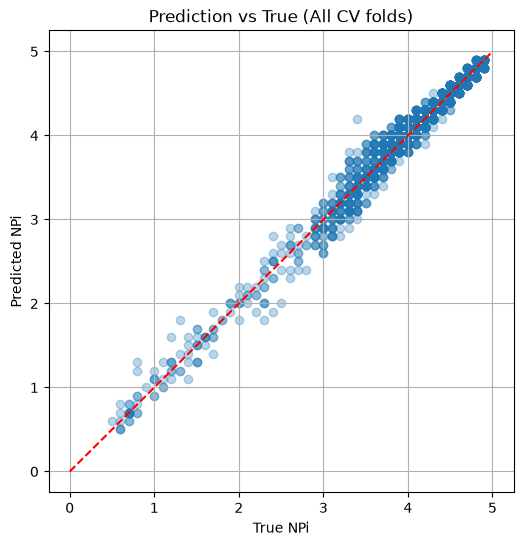

In [5]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)

plt.figure(figsize=(6,6))
plt.scatter(all_true, all_pred, alpha=0.3)

# perfect prediction line
plt.plot([0,5],[0,5],'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True (All CV folds)")
plt.grid()
plt.show()

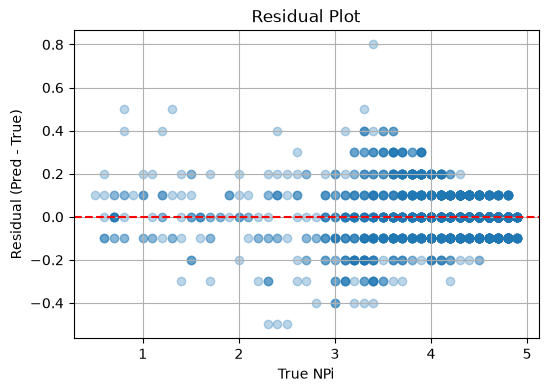

In [6]:
residuals = all_pred - all_true

plt.figure(figsize=(6,4))
plt.scatter(all_true, residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--')

plt.xlabel("True NPi")
plt.ylabel("Residual (Pred - True)")
plt.title("Residual Plot")
plt.grid()
plt.show()

In [7]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_indices = np.array(all_indices)

residuals = all_pred - all_true
errors = np.abs(residuals)

top4_idx = np.argsort(errors)[-2:]
top4_rows = df.iloc[all_indices[top4_idx]].copy()

top4_rows["True NPi"] = all_true[top4_idx]
top4_rows["Predicted NPi"] = all_pred[top4_idx]
top4_rows["Residual"] = residuals[top4_idx]
top4_rows["Abs Error"] = errors[top4_idx]

#print(top4_rows.sort_values("Abs Error", ascending=False)) # Commented out for privacy reasons


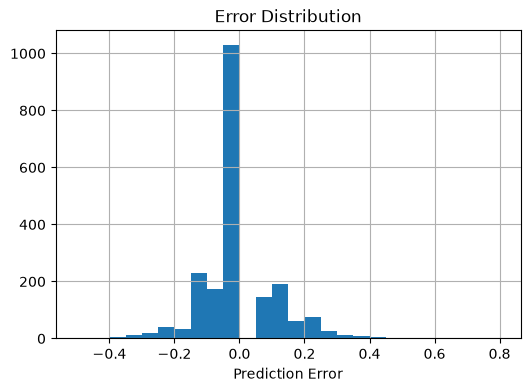

In [8]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=26)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.grid()
plt.show()


In [9]:
results_minmaxch = pd.DataFrame({
    "record_id":              all_indices,
    "redcap_repeat_instance": all_repeat,
    "eye":                    all_eye,
    "y_true":                 all_true,
    "pred_b":                 all_pred
})
results_minmaxch.to_csv("predictions_minmaxch.csv", index=False)

# Final fit

In [10]:
# Final refit on the full data (Not using folds)

# Logit transform
y_scaled = np.clip(y_raw / 5, 1e-6, 1-1e-6)
z = np.log(y_scaled / (1 - y_scaled))

# Fit GAM
gam = LinearGAM(
    s(0, n_splines=20) +
    s(1, constraints='monotonic_dec', n_splines=10) +
    s(2, constraints='monotonic_inc', n_splines=10) 
)

from sklearn.neighbors import KernelDensity

kde = KernelDensity(bandwidth=0.3).fit(z.reshape(-1,1))
log_dens = kde.score_samples(z.reshape(-1,1))
density_weights = 1 / np.exp(log_dens)
density_weights /= density_weights.mean()
cap = np.percentile(density_weights, 95)
density_weights_capped = np.clip(density_weights, None, cap)
density_weights_capped /= density_weights_capped.mean()

gam.gridsearch(X_trans, z, weights=density_weights_capped)

# gam.gridsearch(X_trans, z)

x_vals_size = np.linspace(X_trans.iloc[:,0].min(), X_trans.iloc[:,0].max(), 200)

X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (200,1)),
    columns=X_trans.columns
)
X_fake.iloc[:,0] = x_vals_size

y_gam_size = gam.partial_dependence(term=0, X=X_fake)

params_size, _ = curve_fit(
    pysr_size,
    x_vals_size,
    y_gam_size,
    p0=p0_size,
    maxfev=20000
)


x_vals_min = np.linspace(X_trans.iloc[:,1].min(), X_trans.iloc[:,1].max(), 200)

X_fake.iloc[:,1] = x_vals_min
y_gam_min = gam.partial_dependence(term=1, X=X_fake)

params_min, _ = curve_fit(exp_decay, x_vals_min, y_gam_min, maxfev=20000)


x_vals_ch = np.linspace(X_trans.iloc[:,2].min(), X_trans.iloc[:,2].max(), 200)

X_fake.iloc[:,2] = x_vals_ch
y_gam_ch = gam.partial_dependence(term=2, X=X_fake)

params_ch, _ = curve_fit(
    pysr_ch,
    x_vals_ch,
    y_gam_ch,
    p0=p0_ch,
    maxfev=20000
)

intercept = (
    gam._modelmat(np.zeros((1, X_trans.shape[1]))) @ gam.coef_
).item()


def predict_z_full(X):
    return (
        intercept
        + pysr_size(X.iloc[:,0].values, *params_size)
        + exp_decay(X.iloc[:,1].values, *params_min)
        + pysr_ch(X.iloc[:,2].values, *params_ch)
    )

z_pred = predict_z_full(X_trans)

reg = LinearRegression().fit(
    z_pred.reshape(-1,1),
    z
)

a = reg.coef_[0]
b = reg.intercept_

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
  9% (1 of 11) |##                       | Elapsed Time: 0:00:00 ETA:   0:00:00
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 45% (5 of 11) |###########              | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


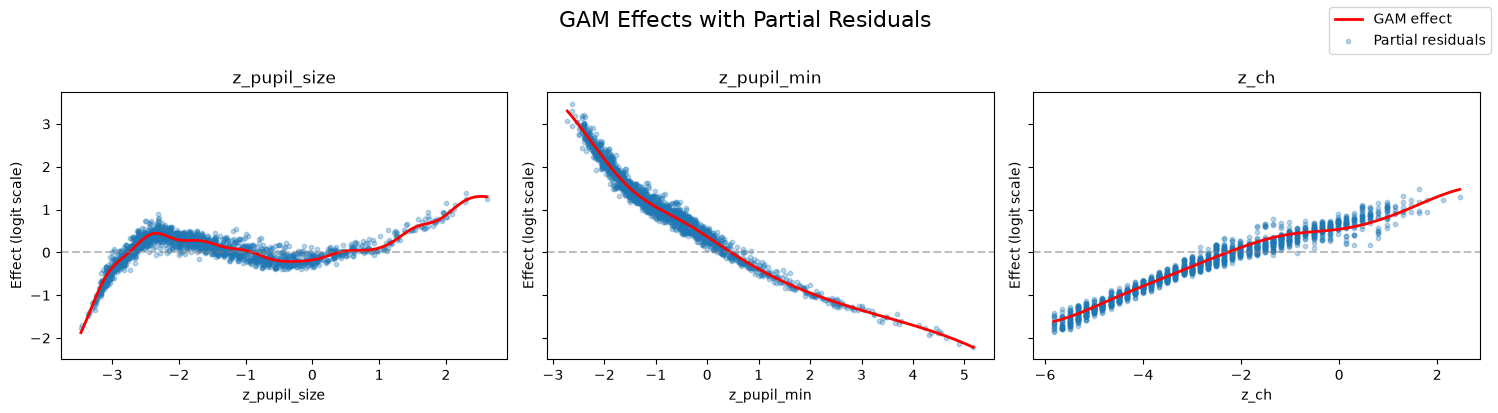

In [11]:
# Plot GAM functions with data

n_features = len(FEATURES)

n_cols = 3
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows),
    sharey=True 
)

axes = axes.flatten()

y_pred = gam.predict(X_trans)

for i in range(n_features):
    ax = axes[i]

    XX = gam.generate_X_grid(term=i)
    pdp = gam.partial_dependence(term=i, X=XX)

    ax.plot(
        XX[:, gam.terms[i].feature],
        pdp,
        color="red",
        linewidth=2,
        label="GAM effect"
    )

    x_vals = X_trans.iloc[:, i].values

    residual = z - y_pred + gam.partial_dependence(term=i, X=X)

    ax.scatter(
        x_vals,
        residual,
        alpha=0.3,
        s=10,
        label="Partial residuals"
    )

    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)

    ax.set_title(FEATURES[i])
    ax.set_xlabel(FEATURES[i])
    ax.set_ylabel("Effect (logit scale)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")

plt.suptitle("GAM Effects with Partial Residuals", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


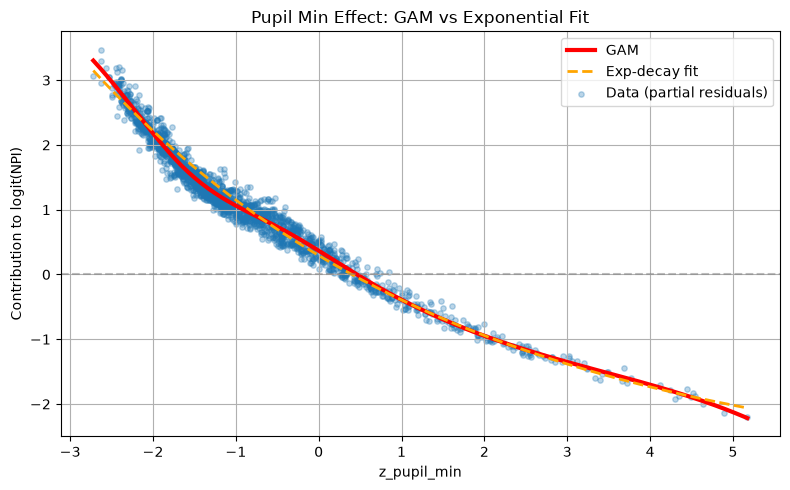

In [12]:
# Additionnally plot biological function

# x interval
x_vals = np.linspace(
    X_trans["z_pupil_min"].min(),
    X_trans["z_pupil_min"].max(),
    200
)

X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (len(x_vals), 1)),
    columns=X_trans.columns
)
X_fake["z_pupil_min"] = x_vals

#  GAM partial dependence 
y_gam = gam.partial_dependence(term=1, X=X_fake)

# fitted curve
params_min, _ = curve_fit(exp_decay, x_vals, y_gam, maxfev=10000)
y_fit = exp_decay(x_vals, *params_min)


# ADD DATAPOINTS

# Predictions
y_pred = gam.predict(X_trans)

# Partial residuals
partial_res = (
    z
    - y_pred
    + gam.partial_dependence(term=1, X=X_trans)
)

# Raw x-values
x_data = X_trans["z_pupil_min"].values


# PLOT
plt.figure(figsize=(8,5))
plt.plot(x_vals, y_gam, color="red",label="GAM", linewidth=3) # GAM curve
plt.plot(x_vals, y_fit, '--',color="orange", label="Exp-decay fit", linewidth=2) # Biological fit

plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("z_pupil_min")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Min Effect: GAM vs Exponential Fit")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

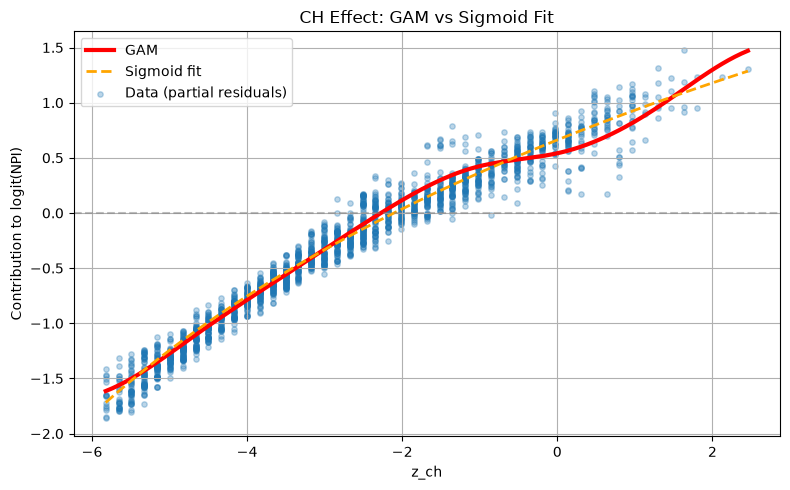

In [13]:
# Identical just for ch

x_vals = np.linspace(
    X_trans["z_ch"].min(),
    X_trans["z_ch"].max(),
    200
)

X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (len(x_vals), 1)),
    columns=X_trans.columns
)
X_fake["z_ch"] = x_vals

y_gam = gam.partial_dependence(term=2, X=X_fake)

p0 = [
    y_gam.max() - y_gam.min(),
    1.0,
    np.median(x_vals),
    np.mean(y_gam)
]
bounds = (
    [0,   0.01, x_vals.min(), -10],
    [10, 10,    x_vals.max(), 10]
)
p0 = np.clip(p0, bounds[0], bounds[1])
params_ch, _ = curve_fit(
    pysr_ch,
    x_vals,
    y_gam,
    p0=p0_ch,
    maxfev=20000
)
y_fit = pysr_ch(x_vals, *params_ch)
y_pred = gam.predict(X_trans)

partial_res = (
    z
    - y_pred
    + gam.partial_dependence(term=2, X=X_trans)
)


x_data = X_trans["z_ch"].values


plt.figure(figsize=(8,5))
plt.plot(x_vals, y_gam,color="red", label="GAM", linewidth=3) # GAM curve
plt.plot(x_vals, y_fit, '--',color="orange", label="Sigmoid fit", linewidth=2) # Parametric fit
# Data points
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("z_ch")
plt.ylabel("Contribution to logit(NPI)")
plt.title("CH Effect: GAM vs Sigmoid Fit")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

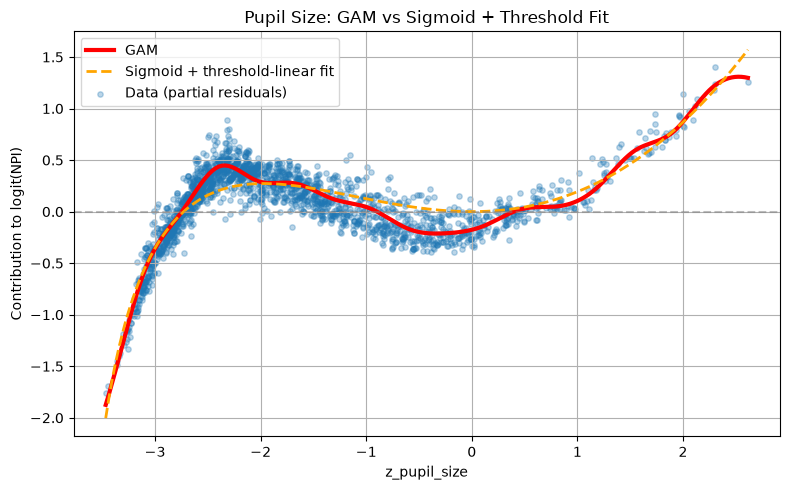

In [14]:
# Identical just for pupil max
x = np.linspace(
    X_trans["z_pupil_size"].min(),
    X_trans["z_pupil_size"].max(),
    200
)

X_fake = pd.DataFrame(
    np.tile(X_trans.mean().values, (len(x), 1)),
    columns=X_trans.columns
)

X_fake["z_pupil_size"] = x

y_gam = gam.partial_dependence(term=0, X=X_fake)

p0 = [
    y_gam.max() - y_gam.min(),  # A
    1.0,                        # k
    np.median(x),               # x0
    0.2,                        # m
    y_gam.min(),             # b
    0.0      
]

bounds=(
                [0, 0.01, x.min(), -5, -10, x.min()],
                [10,10, x.max(),  5,  10,  x.max()]
            )

# ensure valid initial guess
p0 = np.clip(p0, bounds[0], bounds[1])

params_size, _ = curve_fit(
    pysr_size,
    x,
    y_gam,
    p0=p0_size,
    maxfev=20000
)

y_fit = pysr_size(x, *params_size)
y_pred = gam.predict(X_trans)

partial_res = (
    z
    - y_pred
    + gam.partial_dependence(term=0, X=X_trans)
)

x_data = X_trans["z_pupil_size"].values


plt.figure(figsize=(8, 5))
plt.plot(x, y_gam, label="GAM",color="red", linewidth=3) # GAM
plt.plot(x, y_fit, '--',color="orange", label="Sigmoid + threshold-linear fit", linewidth=2) # Parametric fit

# Data
plt.scatter(
    x_data,
    partial_res,
    alpha=0.3,
    s=15,
    label="Data (partial residuals)"
)

plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.xlabel("z_pupil_size")
plt.ylabel("Contribution to logit(NPI)")
plt.title("Pupil Size: GAM vs Sigmoid + Threshold Fit")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
# Performance
z_final = a * z_pred + b
y_pred = np.round(sigmoid(z_final) * 5,1)
rmse = np.sqrt(mean_squared_error(y_raw, y_pred))
mae  = mean_absolute_error(y_raw, y_pred)
r2   = r2_score(y_raw, y_pred)

print("\n=== PERFORMANCE ===")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"R2:   {r2:.4f}")


=== PERFORMANCE ===
RMSE: 0.1026
MAE:  0.0659
R2:   0.9837


In [16]:
params_size

array([0.1243352 , 3.72888058])

In [17]:
params_min

array([ 3.45133945,  0.22163532, -3.15840983])

In [18]:
params_ch

array([0.11729809, 1.24700395])

In [19]:
# Print final model parameters
print("\n=== FINAL MODEL PARAMETERS ===")

print("\n--- SIZE ---")
print(dict(zip(["a","b","c","d"],
    params_size
)))

print("\n--- MIN ---")
print(dict(zip(["a","b","c", "d", "e"],
    params_min
)))

print("\n--- CH ---")
print(dict(zip(["a","b","c","d"],
    params_ch
)))

print("\n--- INTERCEPT ---")
print(intercept)

print("\n--- CALIBRATION ---")
print(f"a = {a:.6f}, b = {b:.6f}")


=== FINAL MODEL PARAMETERS ===

--- SIZE ---
{'a': np.float64(0.12433519680398497), 'b': np.float64(3.7288805847309385)}

--- MIN ---
{'a': np.float64(3.451339454928709), 'b': np.float64(0.22163532274485298), 'c': np.float64(-3.1584098326928975)}

--- CH ---
{'a': np.float64(0.1172980860463615), 'b': np.float64(1.247003948069636)}

--- INTERCEPT ---
1.5548459948536584

--- CALIBRATION ---
a = 1.003080, b = -0.795195


In [20]:
stored_values = {}
stored_values["size"] = params_size
stored_values["min"] = params_min
stored_values["ch"] = params_ch
stored_values["intercept"] = np.array([intercept])
stored_values["a"] = np.array([a])
stored_values["b"] = np.array([b])

pd.DataFrame.from_dict(stored_values, orient='index').to_csv("stored_values.csv")

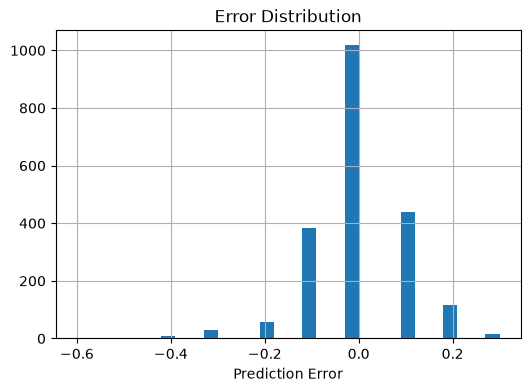

In [21]:
residuals = y_pred-y_raw
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")
plt.grid()
plt.show()


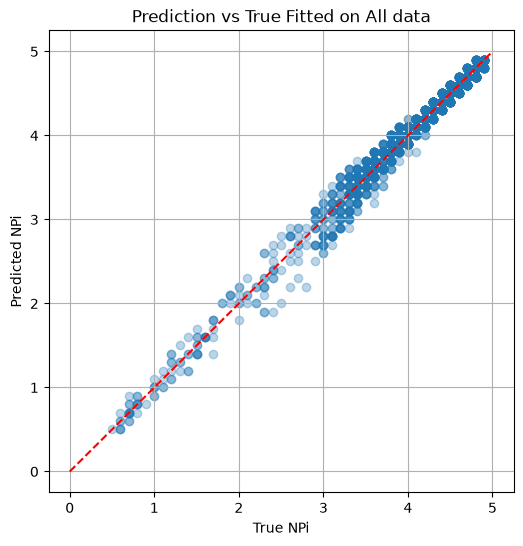

In [22]:
plt.figure(figsize=(6,6))
plt.scatter(y_raw, y_pred, alpha=0.3)

# perfect prediction line
plt.plot([0,5],[0,5],'r--')

plt.xlabel("True NPi")
plt.ylabel("Predicted NPi")
plt.title("Prediction vs True Fitted on All data")
plt.grid()
plt.show()

In [23]:
import sympy as sp

n_digits = 4  # adjust for more/less precision

def to_syms(params):
    return [sp.Float(round(float(v), n_digits)) for v in params]

x_min, x_ch, x_size = sp.symbols('x_min x_ch x_size', real=True)

# --- size ---
a_s, b_s = to_syms(params_size)
size_expr = a_s * x_size**2 * sp.log(x_size + b_s)

# --- min ---
a_m, b_m, c_m = to_syms(params_min)
min_expr = a_m * sp.exp(-b_m * x_min) + c_m

# --- ch ---
a_c, b_c = to_syms(params_ch)
ch_expr = sp.log((a_c * x_ch + b_c)**3)

# --- outer terms (top-level intercept + rescale constants) ---
def to_scalar(v):
    """Coerce a possibly-array-like value (numpy array, list, etc.) to a plain float."""
    return float(np.asarray(v).squeeze())

intercept_s = sp.Float(round(to_scalar(intercept), n_digits))
a_final = sp.Float(round(to_scalar(a), n_digits))
b_final = sp.Float(round(to_scalar(b), n_digits))

# --- combine ---
z_expr = intercept_s + size_expr.expand() + min_expr + ch_expr
z_final_expr = a_final * z_expr + b_final

print("z:")
print(sp.latex(z_expr.simplify()))

print("z_final (after a,b rescale):")
print(sp.latex(z_final_expr))

# --- full NPi expression, including sigmoid ---
npi_expr = 5 / (1 + sp.exp(-z_final_expr))

print("Full NPi expression:")
print(sp.latex(z_final_expr.simplify().evalf(n_digits)))

z:
0.1243 x_{size}^{2} \log{\left(x_{size} + 3.7289 \right)} + \log{\left(\left(0.1173 x_{ch} + 1.247\right)^{3} \right)} - 1.6036 + 3.4513 e^{- 0.2216 x_{min}}
z_final (after a,b rescale):
0.12468533 x_{size}^{2} \log{\left(x_{size} + 3.7289 \right)} + 1.0031 \log{\left(\left(0.1173 x_{ch} + 1.247\right)^{3} \right)} - 2.40377116 + 3.46199903 e^{- 0.2216 x_{min}}
Full NPi expression:
0.1247 x_{size}^{2} \log{\left(x_{size} + 3.7289 \right)} + 1.003 \log{\left(\left(0.1173 x_{ch} + 1.247\right)^{3} \right)} - 2.404 + 3.462 e^{- 0.2216 x_{min}}
